# 02 - Visualizacion de datos

Objetivo: analizar el datamart procesado de AndesMarket S.A.C. mediante KPIs, graficos exploratorios e insights accionables que complementan el tablero de Power BI.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
IMG = ROOT / 'informe' / 'img'
IMG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 10

## 1. Carga del datamart

Se cargan las tablas limpias generadas en la Parte 1. La tabla de hechos se enriquece con categoria de producto, canal, region y atributos temporales para facilitar el analisis visual.

In [2]:
fact = pd.read_csv(DATA / 'fact_ventas.csv', sep=';', parse_dates=['fecha'])
productos = pd.read_csv(DATA / 'dim_producto.csv', sep=';')
tiendas = pd.read_csv(DATA / 'dim_tienda.csv', sep=';')
clientes = pd.read_csv(DATA / 'dim_cliente.csv', sep=';')
tiempo = pd.read_csv(DATA / 'dim_tiempo.csv', sep=';', parse_dates=['fecha'])

df = (
    fact.merge(productos[['id_producto', 'nombre', 'categoria', 'subcategoria', 'marca']], on='id_producto', how='left')
        .merge(tiendas[['id_tienda', 'canal', 'region', 'ciudad']], on='id_tienda', how='left')
        .merge(clientes[['id_cliente', 'segmento_programa', 'distrito']], on='id_cliente', how='left')
)
df['mes'] = df['fecha'].dt.to_period('M').dt.to_timestamp()
df['anio'] = df['fecha'].dt.year
df['mes_num'] = df['fecha'].dt.month

df.head()

,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,...,subcategoria,marca,canal,region,ciudad,segmento_programa,distrito,mes,anio,mes_num
0,V0027569,2025-08-28,C01502,P0162,T015,PR000,1,37.62,0.0,37.62,...,Aceite,Premium,online,Nacional,Online,Bronce,Ate,2025-08-01,2025,8
1,V0018420,2025-09-27,C00706,P0362,T002,PR000,1,5.62,0.0,5.62,...,Lavavajilla,Ayni,fisico,Lima,Lima,Bronce,Surco,2025-09-01,2025,9
2,V0010328,2024-12-12,C04281,P0113,T014,PR000,1,48.35,0.0,48.35,...,Conservas,Inti,fisico,Norte,Cajamarca,Bronce,Cusco,2024-12-01,2024,12
3,V0018216,2025-12-29,C01722,P0151,T009,PR000,1,12.68,0.0,12.68,...,Arroz,Andes,fisico,Norte,Trujillo,Bronce,Arequipa,2025-12-01,2025,12
4,V0019843,2024-03-10,C02654,P0186,T011,PR000,1,11.86,0.0,11.86,...,Keke,Andes,fisico,Norte,Chiclayo,Plata,Miraflores,2024-03-01,2024,3


## 2. KPIs generales

Estos indicadores resumen el desempeno comercial del datamart y sirven como referencia para las paginas principales de Power BI.

In [3]:
kpis = pd.DataFrame({
    'kpi': [
        'Ventas totales', 'Margen bruto', 'Margen %', 'Ticket promedio',
        'Clientes unicos', 'Ventas/lineas', 'Productos vendidos'
    ],
    'valor': [
        df['importe'].sum(),
        df['margen'].sum(),
        df['margen'].sum() / df['importe'].sum(),
        df.groupby('id_venta')['importe'].sum().mean(),
        df['id_cliente'].nunique(),
        len(df),
        df['id_producto'].nunique(),
    ]
})
kpis

,kpi,valor
0,Ventas totales,2.820046e+06
1,Margen bruto,8.615058e+05
2,Margen %,3.054935e-01
3,Ticket promedio,8.620831e+01
4,Clientes unicos,4.955000e+03
5,Ventas/lineas,5.964300e+04
6,Productos vendidos,5.000000e+02


## 3. Evolucion mensual de ventas y margen

Permite identificar estacionalidad y meses relevantes para planificacion comercial.

,mes,ventas,margen
19,2025-08-01,121343.3650,37682.2550
20,2025-09-01,69381.0035,20188.5935
21,2025-10-01,94606.9170,29734.8770
22,2025-11-01,90617.5685,28636.7985
23,2025-12-01,141983.9900,45846.7600


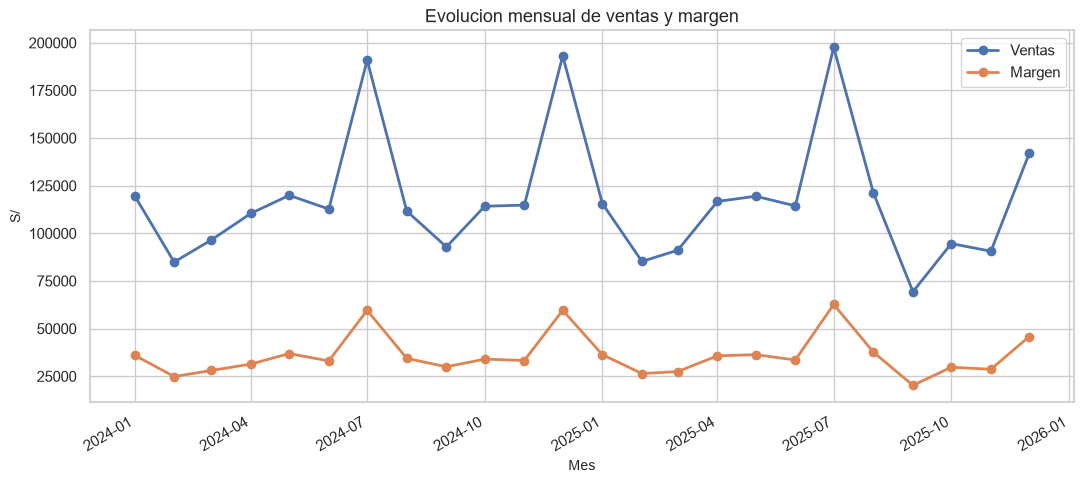

In [4]:
mensual = df.groupby('mes', as_index=False).agg(ventas=('importe', 'sum'), margen=('margen', 'sum'))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mensual['mes'], mensual['ventas'], marker='o', linewidth=2, label='Ventas')
ax.plot(mensual['mes'], mensual['margen'], marker='o', linewidth=2, label='Margen')
ax.set_title('Evolucion mensual de ventas y margen')
ax.set_xlabel('Mes')
ax.set_ylabel('S/')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(IMG / 'ventas_margen_mensual.png', dpi=140)
mensual.tail()

## 4. Ventas y margen por categoria

Compara volumen de ventas y rentabilidad para priorizar categorias.

,categoria,ventas,margen,lineas
1,Bebidas,479990.7810,153928.1410,10188
9,Snacks,415072.6145,130011.0245,9847
6,Lacteos,338425.2640,106192.9540,6887
0,Abarrotes,327164.3025,91590.0325,6524
7,Limpieza,313019.6425,95825.6025,7306
8,Panaderia,302011.0365,88620.2265,6433
2,Carnes,287979.3520,83391.3120,5613
3,Congelados,267244.5010,83326.0210,5045
5,Frutas y verduras,47725.0260,15573.5460,968
4,Cuidado personal,41413.7215,13046.8915,832


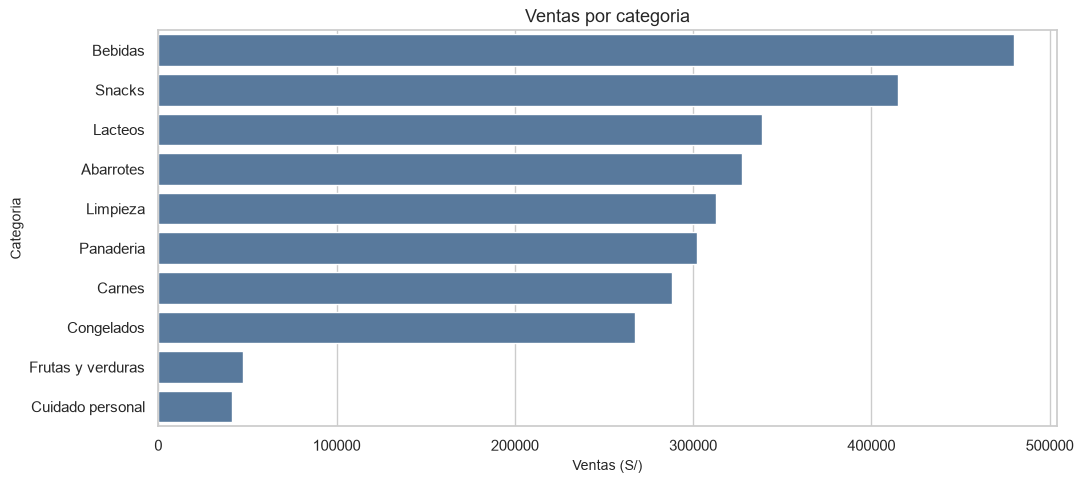

In [5]:
categoria = (
    df.groupby('categoria', as_index=False)
      .agg(ventas=('importe', 'sum'), margen=('margen', 'sum'), lineas=('id_venta', 'count'))
      .sort_values('ventas', ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=categoria, x='ventas', y='categoria', ax=ax, color='#4C78A8')
ax.set_title('Ventas por categoria')
ax.set_xlabel('Ventas (S/)')
ax.set_ylabel('Categoria')
fig.tight_layout()
fig.savefig(IMG / 'ventas_por_categoria.png', dpi=140)
categoria

## 5. Pareto de productos

Evalua si pocos productos concentran una parte importante de las ventas.

,id_producto,nombre,ventas,ventas_acum_pct,rank_pct
73,P0074,Gaseosa Norte 074,28760.2425,0.010199,0.002
403,P0404,Papas Premium 404,24727.4015,0.018967,0.004
374,P0375,Platano Ayni 375,23144.2885,0.027174,0.006
274,P0275,Desinfectante Premium 275,23036.0205,0.035343,0.008
407,P0408,Pizza Andes 408,21981.8350,0.043138,0.010
15,P0016,Hamburguesa Premium 016,21389.8035,0.050722,0.012
104,P0105,Embutidos Andes 105,20126.3020,0.057859,0.014
339,P0340,Frutos secos Andes 340,20000.4150,0.064952,0.016
198,P0199,Agua Norte 199,18857.7030,0.071639,0.018
388,P0389,Embutidos Valle 389,18660.6285,0.078256,0.020


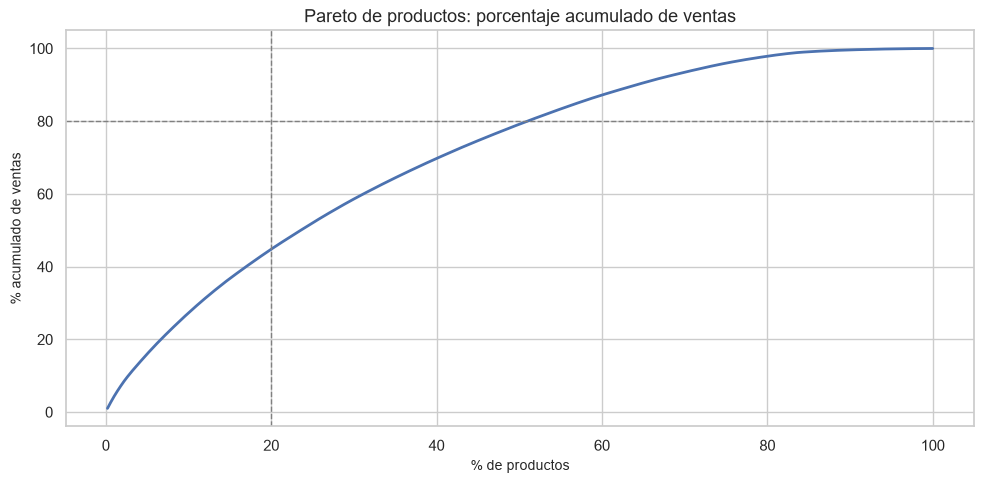

In [6]:
producto = (
    df.groupby(['id_producto', 'nombre'], as_index=False)
      .agg(ventas=('importe', 'sum'))
      .sort_values('ventas', ascending=False)
)
producto['ventas_acum_pct'] = producto['ventas'].cumsum() / producto['ventas'].sum()
producto['rank_pct'] = range(1, len(producto) + 1)
producto['rank_pct'] = producto['rank_pct'] / len(producto)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(producto['rank_pct'] * 100, producto['ventas_acum_pct'] * 100, linewidth=2)
ax.axvline(20, color='gray', linestyle='--', linewidth=1)
ax.axhline(80, color='gray', linestyle='--', linewidth=1)
ax.set_title('Pareto de productos: porcentaje acumulado de ventas')
ax.set_xlabel('% de productos')
ax.set_ylabel('% acumulado de ventas')
fig.tight_layout()
fig.savefig(IMG / 'pareto_productos.png', dpi=140)
producto.head(10)

## 6. Ventas por canal y region

Muestra el aporte relativo de tiendas fisicas y canal online, ademas de la distribucion regional.

,canal,region,ventas,margen
2,fisico,Lima,917736.5195,280395.0995
3,fisico,Norte,735129.3610,225938.3710
4,fisico,Sur,551704.1805,168743.8705
5,online,Nacional,248390.6895,74759.9695
0,fisico,Callao,184409.4315,56671.1515
1,fisico,Centro,182676.0595,54997.2895


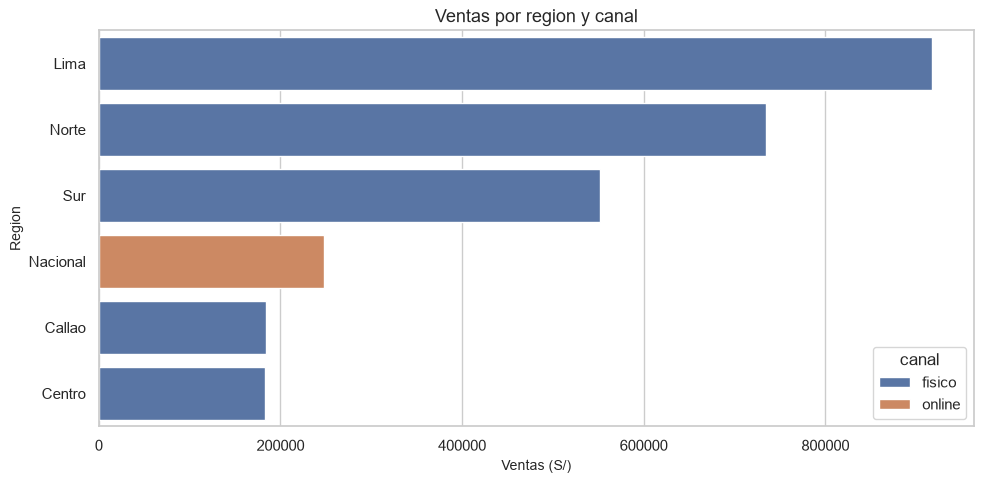

In [7]:
canal_region = (
    df.groupby(['canal', 'region'], as_index=False)
      .agg(ventas=('importe', 'sum'), margen=('margen', 'sum'))
      .sort_values('ventas', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=canal_region, x='ventas', y='region', hue='canal', ax=ax)
ax.set_title('Ventas por region y canal')
ax.set_xlabel('Ventas (S/)')
ax.set_ylabel('Region')
fig.tight_layout()
fig.savefig(IMG / 'ventas_region_canal.png', dpi=140)
canal_region

## 7. Mapa de calor mes-categoria

Permite detectar categorias con comportamiento estacional.

mes_num,1,2,3,4,5,6,7,8,9,10,11,12
categoria,,,,,,,,,,,,
Abarrotes,0.088,0.060,0.066,0.078,0.086,0.081,0.137,0.087,0.055,0.075,0.073,0.114
Bebidas,0.080,0.065,0.067,0.082,0.086,0.080,0.139,0.083,0.058,0.069,0.066,0.124
Carnes,0.091,0.063,0.063,0.081,0.088,0.088,0.138,0.078,0.053,0.079,0.058,0.119
Congelados,0.081,0.058,0.070,0.082,0.089,0.078,0.141,0.086,0.059,0.081,0.063,0.113
Cuidado personal,0.089,0.044,0.063,0.076,0.091,0.086,0.149,0.082,0.046,0.078,0.067,0.128
Frutas y verduras,0.100,0.075,0.059,0.072,0.091,0.084,0.116,0.083,0.047,0.081,0.078,0.113
Lacteos,0.081,0.053,0.068,0.085,0.084,0.088,0.135,0.081,0.058,0.068,0.078,0.120
Limpieza,0.084,0.063,0.066,0.079,0.087,0.082,0.136,0.078,0.055,0.070,0.078,0.122
Panaderia,0.085,0.061,0.066,0.076,0.073,0.074,0.135,0.084,0.065,0.073,0.088,0.119


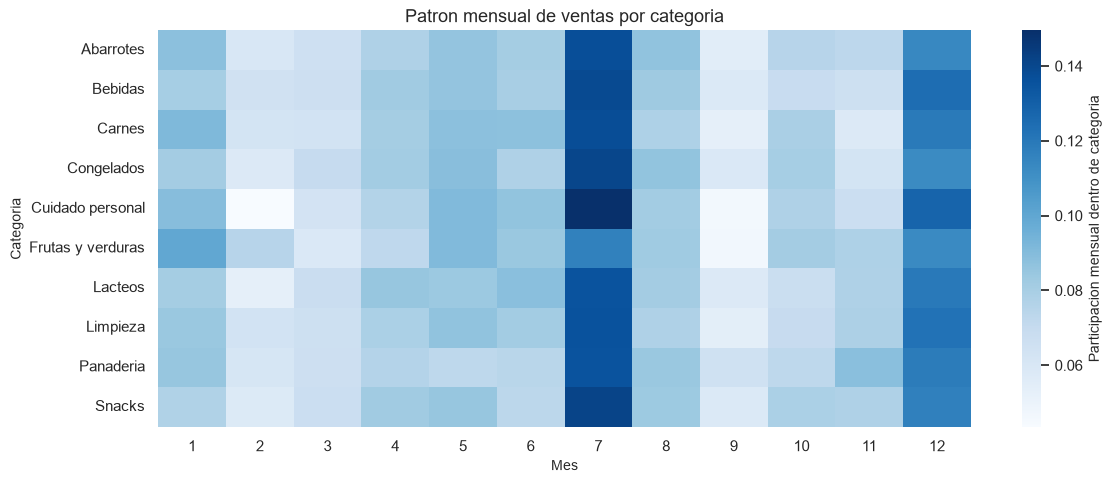

In [8]:
heat = df.pivot_table(index='categoria', columns='mes_num', values='importe', aggfunc='sum', fill_value=0)
heat_pct = heat.div(heat.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_pct, cmap='Blues', ax=ax, cbar_kws={'label': 'Participacion mensual dentro de categoria'})
ax.set_title('Patron mensual de ventas por categoria')
ax.set_xlabel('Mes')
ax.set_ylabel('Categoria')
fig.tight_layout()
fig.savefig(IMG / 'heatmap_mes_categoria.png', dpi=140)
heat_pct.round(3)

## 8. Insights accionables

Se consolidan hallazgos que deben trasladarse al informe y al tablero ejecutivo de Power BI.

In [9]:
top_categoria = categoria.iloc[0]
top_region = df.groupby('region')['importe'].sum().sort_values(ascending=False).index[0]
top_mes = mensual.sort_values('ventas', ascending=False).iloc[0]
pareto_20 = producto.loc[producto['rank_pct'].le(0.20), 'ventas'].sum() / producto['ventas'].sum()
online_share = df.loc[df['canal'].eq('online'), 'importe'].sum() / df['importe'].sum()
margen_pct = df['margen'].sum() / df['importe'].sum()

insights = pd.DataFrame([
    {
        'hallazgo': f"La categoria con mayor venta es {top_categoria['categoria']}, con S/ {top_categoria['ventas']:,.0f}.",
        'recomendacion': 'Priorizar disponibilidad, exhibicion y promociones selectivas en esta categoria para sostener el volumen.'
    },
    {
        'hallazgo': f"El mes de mayor venta es {top_mes['mes'].strftime('%Y-%m')}, con S/ {top_mes['ventas']:,.0f}.",
        'recomendacion': 'Preparar inventario y campanas antes de los picos estacionales, especialmente julio y diciembre.'
    },
    {
        'hallazgo': f"El 20% superior de productos concentra aproximadamente {pareto_20:.1%} de las ventas.",
        'recomendacion': 'Gestionar los productos clave con seguimiento semanal de stock, precio y margen.'
    },
    {
        'hallazgo': f"La region con mayor aporte de ventas es {top_region}.",
        'recomendacion': 'Usar la region lider como referencia para replicar surtido y campanas en regiones con menor desempeno.'
    },
    {
        'hallazgo': f"El canal online representa {online_share:.1%} de las ventas totales.",
        'recomendacion': 'Monitorear el canal online como unidad diferenciada y evaluar acciones de fidelizacion digital.'
    },
    {
        'hallazgo': f"El margen bruto global es {margen_pct:.1%}.",
        'recomendacion': 'Combinar analisis de ventas con margen para evitar decisiones basadas solo en volumen.'
    },
])

md = '# Insights de visualizacion\n\n'
for i, row in insights.iterrows():
    md += f"{i + 1}. **Hallazgo:** {row['hallazgo']}  \n"
    md += f"   **Recomendacion:** {row['recomendacion']}\n\n"

(ROOT / 'informe' / 'insights_visualizacion.md').write_text(md, encoding='utf-8')
insights

,hallazgo,recomendacion
0,"La categoria con mayor venta es Bebidas, con S...","Priorizar disponibilidad, exhibicion y promoci..."
1,"El mes de mayor venta es 2025-07, con S/ 197,586.",Preparar inventario y campanas antes de los pi...
2,El 20% superior de productos concentra aproxim...,Gestionar los productos clave con seguimiento ...
3,La region con mayor aporte de ventas es Lima.,Usar la region lider como referencia para repl...
4,El canal online representa 8.8% de las ventas ...,Monitorear el canal online como unidad diferen...
5,El margen bruto global es 30.5%.,Combinar analisis de ventas con margen para ev...


## 9. Salidas para el informe

Graficos exportados en `informe/img/`:

- `ventas_margen_mensual.png`
- `ventas_por_categoria.png`
- `pareto_productos.png`
- `ventas_region_canal.png`
- `heatmap_mes_categoria.png`

Insights exportados en `informe/insights_visualizacion.md`.